In [1]:
#==================================================
# Imports
#==================================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
import matplotlib
import os
#import h5py
import PseudoNetCDF as pnc
from scipy.ndimage import label
import scipy.interpolate as interp
import pickle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec
from scipy.integrate import cumulative_trapezoid as scitrapz
import scipy
plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
#=======================================
# Diagnostics Parameters
#=======================================
space = '    '
#=======================================
# Functions
#=======================================
def print_diag(key,var):
    print(key)
    print(space,'Shape:',np.shape(var))
    print(space,'Max:',np.max(var))
    print(space,'Min:',np.min(var))
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

In [10]:
path = '/pscratch/sd/m/mckenna/dharma_post/'
file_name = path+'obs_cloud_pass_dict.p'
obs_dict = learjet_dict = pickle.load(open(file_name,"rb"))

In [11]:
obs_dict.keys()

dict_keys(['lj_cp_pos1', 'lj_cp1_neg7', 'lj_cp2_neg7', 'p3_cp1_neg11', 'lj_cp1_neg15', 'lj_cp2_neg15'])

In [13]:
target_obs_temp_1 = np.mean([obs_dict['lj_cp1_neg7']['mean_temp'],obs_dict['lj_cp2_neg7']['mean_temp']])
target_obs_temp_2 = obs_dict['p3_cp1_neg11']['mean_temp']
target_obs_temp_3 = np.mean([obs_dict['lj_cp1_neg15']['mean_temp'],obs_dict['lj_cp2_neg15']['mean_temp']])
target_obs_temps = [target_obs_temp_1,target_obs_temp_2,target_obs_temp_3]

In [7]:
path = '/pscratch/sd/m/mckenna/dharma_post/'

# CNTL BIN
sim_name = 'cntl_bin_ice'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
cntl_bin_dict = pickle.load(open(file_name,"rb"))

# SIP BIN
sim_name = 'sip_bin_ice'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
sip_bin_dict = pickle.load(open(file_name,"rb"))

# SIP 10X BIN
sim_name = 'sip_10x_bin_ice'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
sip_10x_bin_dict = pickle.load(open(file_name,"rb"))

# CNTL BIN NOTURB
sim_name = 'cntl_bin_ice_noturb'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
cntl_bin_noturb_dict = pickle.load(open(file_name,"rb"))

# SIP 10X BIN NOTURB
sim_name = 'sip_10x_bin_ice_noturb'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
sip_10x_bin_noturb_dict = pickle.load(open(file_name,"rb"))

# CNTL BULK
sim_name = 'cntl_bulk_ice_ABIFM'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
cntl_bulk_dict = pickle.load(open(file_name,"rb"))

# SIP BULK
sim_name = 'sip_bulk_ice_ABIFM'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
sip_bulk_dict = pickle.load(open(file_name,"rb"))

# SIP 10X BULK
sim_name = 'sip_10x_bulk_ice_ABIFM'
file_name = path+'{}_cloud_pass_dict.p'.format(sim_name)
sip_10x_bulk_dict = pickle.load(open(file_name,"rb"))

# Plot Bin Total PSDs

/tmp/ipykernel_806027/2709418683.py:159: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


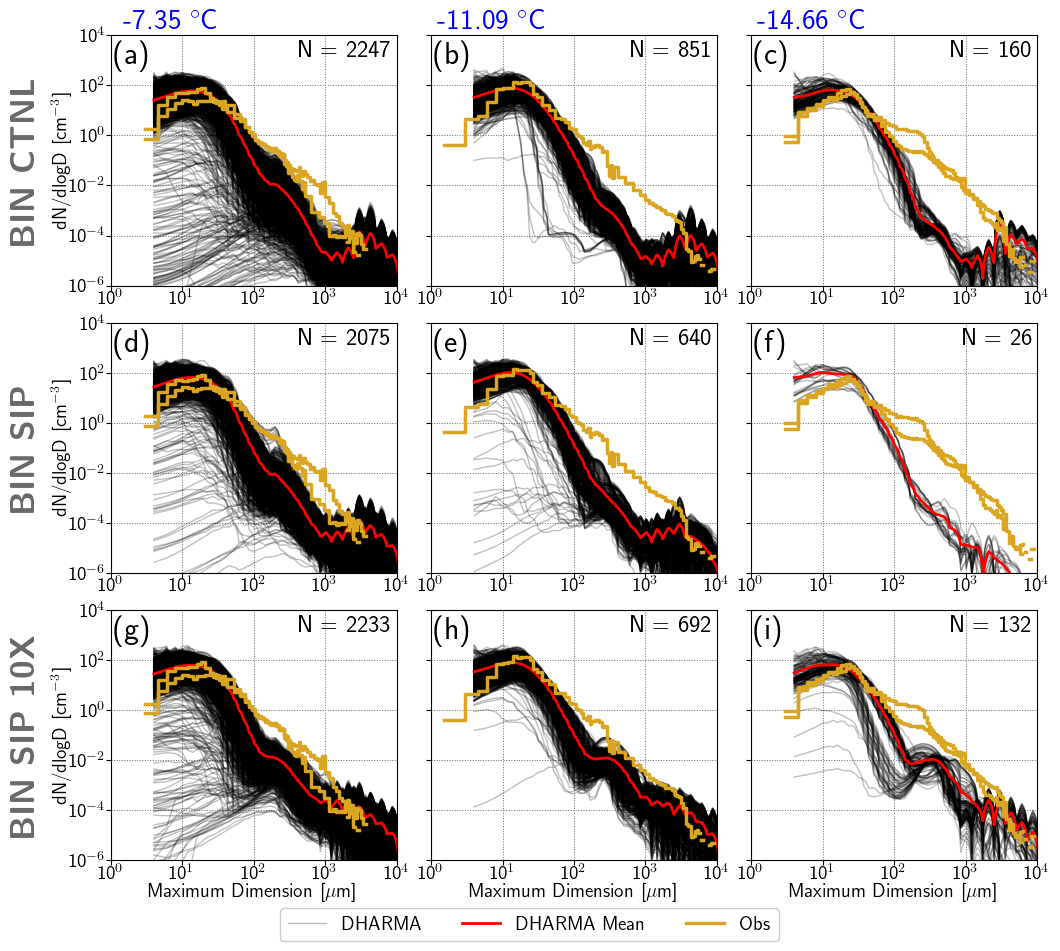

done


In [8]:
n_obs = 3
fig,axes = plt.subplots(nrows=3,ncols=n_obs,figsize=(3.5*n_obs, 9),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14

diam_liq = sip_bin_dict['lj_neg7']['diam_liq']
diam_ice = sip_bin_dict['lj_neg7']['diam_ice']
diam_tot = sip_bin_dict['lj_neg7']['diam_tot']

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])



left_axes = [axes_flat[0], axes_flat[n_obs], axes_flat[2*n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    #ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

bottom_axes = axes_flat[2*n_obs:]
for ax in bottom_axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]
axes_flat_3 = axes_flat[2*n_obs:]

obs_color = 'goldenrod'
dharma_mean_color = 'red'
dharma_color = 'black'
dharma_alpha=0.25

# --- Row 1: SIP ---
dumi=0
for key in cntl_bin_dict.keys():
    dNdlogD_arr  = cntl_bin_dict[key]['up_w_dNdlogD']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_1[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='DHARMA Mean')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1

# --- Row 2: SIP ---
dumi=0
for key in sip_bin_dict.keys():
    dNdlogD_arr  = sip_bin_dict[key]['up_w_dNdlogD']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_2[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='DHARMA Mean')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1

# --- Row 3: SIP 10X ---
dumi=0
for key in sip_10x_bin_dict.keys():
    dNdlogD_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_3[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_3[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='DHARMA Mean')
    axes_flat_3[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_3[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 0 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_3[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1


for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#lgnd=axes_flat_3[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
#lgnd=axes_flat_3[0].legend(loc='lower left',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(0.,-0.5),labelspacing=0.1,borderpad=0.4,ncol=3)
#lgnd=axes_flat_1[1].legend(loc='lower left',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(-0.15,0.),labelspacing=0.1,borderpad=0.5,ncol=1,edgecolor='k')
#lgnd.set_in_layout(False)
# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.05), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=3)                     # Number of columns

#plt.suptitle('Updrafts Only ($w$ $>$ 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.3,0.5,r'\textbf{BIN CTNL}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.3,0.5,r'\textbf{BIN SIP}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')
axes_flat_3[0].text(-0.3,0.5,r'\textbf{BIN SIP 10X}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_3[0].transAxes,c='dimgrey')

save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_total_PSDs_bin.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

/tmp/ipykernel_806027/392867984.py:151: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


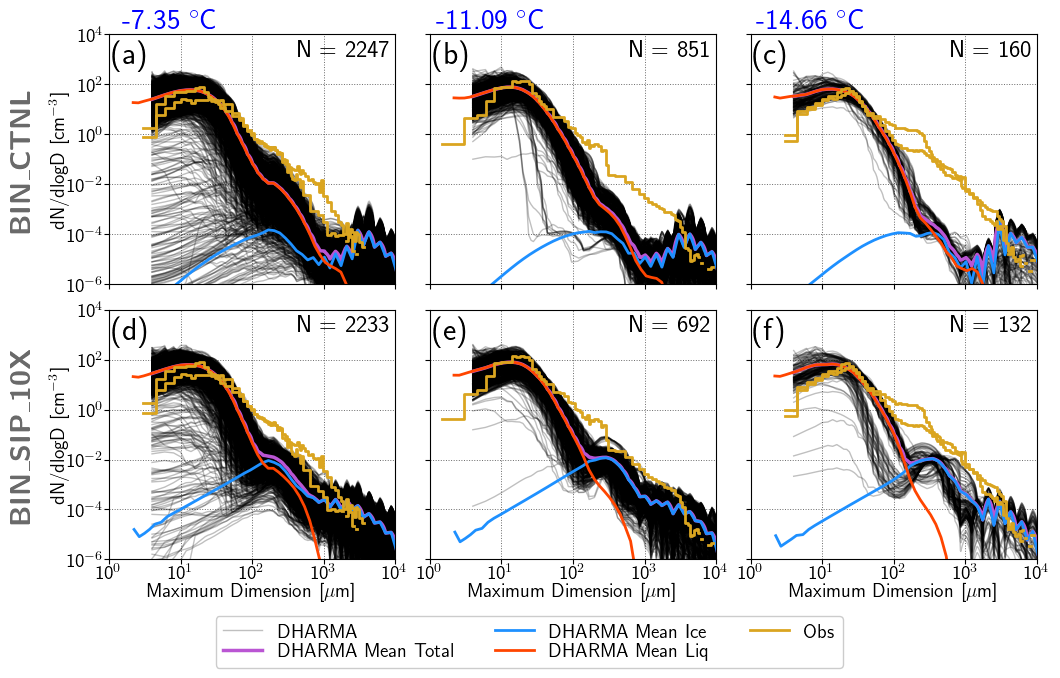

done


In [14]:
n_obs = 3
fig,axes = plt.subplots(nrows=2,ncols=n_obs,figsize=(3.5*n_obs, 6),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14

diam_liq = sip_bin_dict['lj_neg7']['diam_liq']
diam_ice = sip_bin_dict['lj_neg7']['diam_ice']
diam_tot = sip_bin_dict['lj_neg7']['diam_tot']

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])



left_axes = [axes_flat[0], axes_flat[n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    #ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

bottom_axes = axes_flat[1*n_obs:]
for ax in bottom_axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)

top_axes = axes_flat[0*n_obs:1*n_obs]
for ax in top_axes:
    ax.set_xticklabels([])

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]

obs_color = 'goldenrod'
dharma_mean_color = 'mediumorchid'
dharma_mean_ice_color = 'dodgerblue'
dharma_mean_liq_color = 'orangered'
dharma_color = 'black'
dharma_alpha=0.25

# --- Row 1: SIP ---
dumi=0
for key in cntl_bin_dict.keys():
    dNdlogD_arr  = cntl_bin_dict[key]['up_w_dNdlogD']
    dNdlogD_ice_arr  = cntl_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_liq_arr  = cntl_bin_dict[key]['up_w_dNdlogD_liq']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_1[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2.5, label='DHARMA Mean Total')
    axes_flat_1[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='DHARMA Mean Ice')
    axes_flat_1[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='DHARMA Mean Liq')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1

# --- Row 3: SIP 10X ---
dumi=0
for key in sip_10x_bin_dict.keys():
    dNdlogD_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD']
    dNdlogD_ice_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_liq_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_liq']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_2[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2.5, label='DHARMA Mean Total')
    axes_flat_2[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='DHARMA Mean Ice')
    axes_flat_2[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='DHARMA Mean Liq')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 0 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1


for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.1215), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=3)                     # Number of columns

#plt.suptitle('Updrafts Only ($w$ $>$ 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.3,0.5,r'\textbf{BIN_CTNL}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.3,0.5,r'\textbf{BIN_SIP_10X}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')

save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_total_PSDs_bin.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# Plot bulk total PSDs

/tmp/ipykernel_627675/1004869987.py:183: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


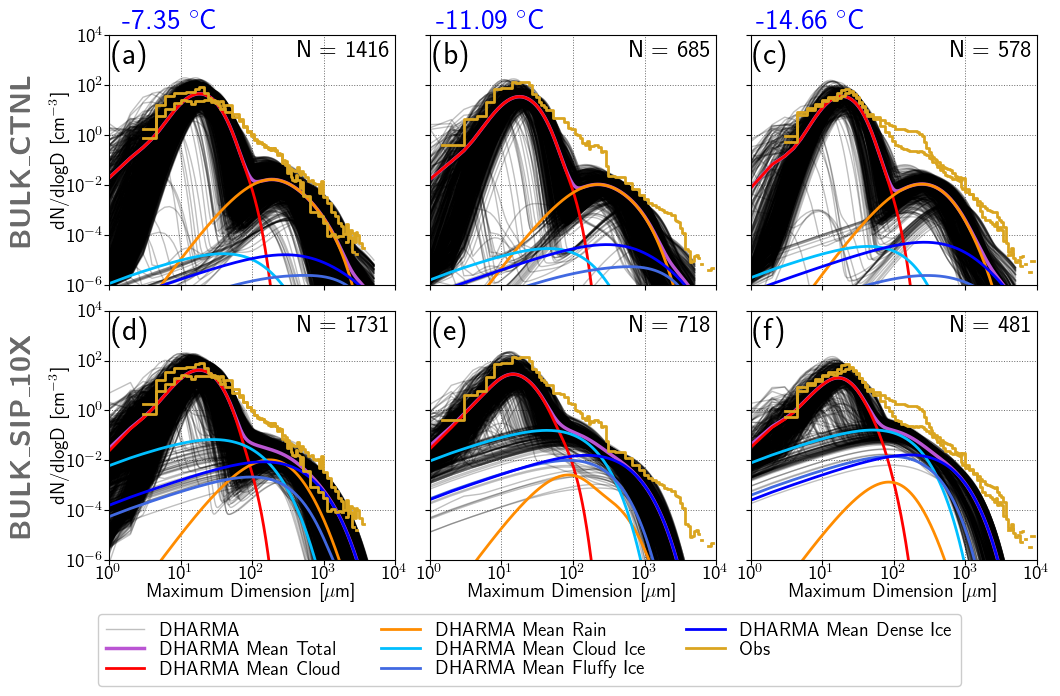

done


In [7]:
n_obs = 3
fig,axes = plt.subplots(nrows=2,ncols=n_obs,figsize=(3.5*n_obs, 6),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14


diam_tot = cntl_bulk_dict['lj_neg7']['diam_tot']

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])



left_axes = [axes_flat[0], axes_flat[n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    #ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

bottom_axes = axes_flat[1*n_obs:]
for ax in bottom_axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)

top_axes = axes_flat[0*n_obs:1*n_obs]
for ax in top_axes:
    ax.set_xticklabels([])

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]

obs_color = 'goldenrod'
#obs_color = 'saddlebrown'
#obs_color = 'magenta'
dharma_mean_color = 'mediumorchid'
#dharma_mean_ice_color = 'dodgerblue'
#dharma_mean_liq_color = 'orangered'
dharma_mean_cloud_ice_color = 'deepskyblue'
dharma_mean_fluffy_ice_color = 'royalblue'
dharma_mean_dense_ice_color = 'blue'
dharma_mean_cloud_color = 'red'
dharma_mean_rain_color = 'darkorange'

dharma_color = 'black'
dharma_alpha=0.25


# --- Row 1: SIP ---
dumi=0
for key in cntl_bin_dict.keys():
    dNdlogD_arr  = cntl_bulk_dict[key]['up_w_dNdlogD']
    dNdlogD_cloud_arr  = cntl_bulk_dict[key]['up_w_dNdlogD_cloud']
    dNdlogD_rain_arr  = cntl_bulk_dict[key]['up_w_dNdlogD_rain']
    dNdlogD_cloud_ice_arr  = cntl_bulk_dict[key]['up_w_dNdlogD_cloud_ice']
    dNdlogD_fluffy_ice_arr  = cntl_bulk_dict[key]['up_w_dNdlogD_fluffy_ice']
    dNdlogD_dense_ice_arr  = cntl_bulk_dict[key]['up_w_dNdlogD_dense_ice']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_cloud = np.mean(dNdlogD_cloud_arr, axis=0)
    mean_dNdlogD_rain = np.mean(dNdlogD_rain_arr, axis=0)
    mean_dNdlogD_cloud_ice = np.mean(dNdlogD_cloud_ice_arr, axis=0)
    mean_dNdlogD_fluffy_ice = np.mean(dNdlogD_fluffy_ice_arr, axis=0)
    mean_dNdlogD_dense_ice = np.mean(dNdlogD_dense_ice_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_cloud[mean_dNdlogD_cloud == 0.] = np.nan
    mean_dNdlogD_rain[mean_dNdlogD_rain == 0.] = np.nan
    mean_dNdlogD_cloud_ice[mean_dNdlogD_cloud_ice == 0.] = np.nan
    mean_dNdlogD_fluffy_ice[mean_dNdlogD_fluffy_ice == 0.] = np.nan
    mean_dNdlogD_dense_ice[mean_dNdlogD_dense_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_1[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2.5, label='DHARMA Mean Total')
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD_cloud, c=dharma_mean_cloud_color, lw=2., label='DHARMA Mean Cloud')
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD_rain, c=dharma_mean_rain_color, lw=2., label='DHARMA Mean Rain')
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD_cloud_ice, c=dharma_mean_cloud_ice_color, lw=2., label='DHARMA Mean Cloud Ice')
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD_fluffy_ice, c=dharma_mean_fluffy_ice_color, lw=2., label='DHARMA Mean Fluffy Ice')
    axes_flat_1[dumi].plot(diam_tot, mean_dNdlogD_dense_ice, c=dharma_mean_dense_ice_color, lw=2., label='DHARMA Mean Dense Ice')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1


# --- Row 3: SIP 10X ---
dumi=0
for key in sip_10x_bin_dict.keys():
    dNdlogD_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD']
    dNdlogD_cloud_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD_cloud']
    dNdlogD_rain_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD_rain']
    dNdlogD_cloud_ice_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD_cloud_ice']
    dNdlogD_fluffy_ice_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD_fluffy_ice']
    dNdlogD_dense_ice_arr  = sip_10x_bulk_dict[key]['up_w_dNdlogD_dense_ice']
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_cloud = np.mean(dNdlogD_cloud_arr, axis=0)
    mean_dNdlogD_rain = np.mean(dNdlogD_rain_arr, axis=0)
    mean_dNdlogD_cloud_ice = np.mean(dNdlogD_cloud_ice_arr, axis=0)
    mean_dNdlogD_fluffy_ice = np.mean(dNdlogD_fluffy_ice_arr, axis=0)
    mean_dNdlogD_dense_ice = np.mean(dNdlogD_dense_ice_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_cloud[mean_dNdlogD_cloud == 0.] = np.nan
    mean_dNdlogD_rain[mean_dNdlogD_rain == 0.] = np.nan
    mean_dNdlogD_cloud_ice[mean_dNdlogD_cloud_ice == 0.] = np.nan
    mean_dNdlogD_fluffy_ice[mean_dNdlogD_fluffy_ice == 0.] = np.nan
    mean_dNdlogD_dense_ice[mean_dNdlogD_dense_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA' if ii == 0 else None
        tmp_dNdlogD_arr = dNdlogD_arr[ii,:]
        tmp_dNdlogD_arr[tmp_dNdlogD_arr == 0.] = np.nan
        axes_flat_2[dumi].plot(diam_tot, tmp_dNdlogD_arr, c=dharma_color, lw=1, alpha=dharma_alpha, label=lbl)
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2.5, label='DHARMA Mean Total')
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD_cloud, c=dharma_mean_cloud_color, lw=2., label='DHARMA Mean Cloud')
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD_rain, c=dharma_mean_rain_color, lw=2., label='DHARMA Mean Rain')
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD_cloud_ice, c=dharma_mean_cloud_ice_color, lw=2., label='DHARMA Mean Cloud Ice')
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD_fluffy_ice, c=dharma_mean_fluffy_ice_color, lw=2., label='DHARMA Mean Fluffy Ice')
    axes_flat_2[dumi].plot(diam_tot, mean_dNdlogD_dense_ice, c=dharma_mean_dense_ice_color, lw=2., label='DHARMA Mean Dense Ice')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.15), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=3)                     # Number of columns

#plt.suptitle('Updrafts Only ($w$ $>$ 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.3,0.5,r'\textbf{BULK_CTNL}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.3,0.5,r'\textbf{BULK_SIP_10X}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')

save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_total_PSDs_bulk.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

/tmp/ipykernel_627675/3959436955.py:135: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


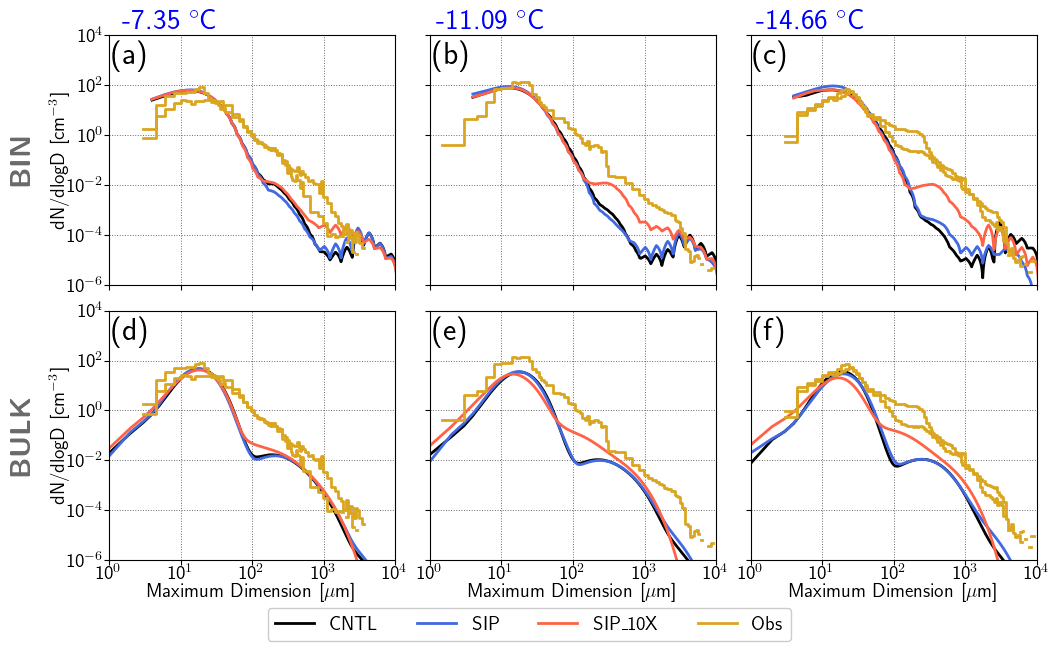

done


In [8]:
n_obs = 3
fig,axes = plt.subplots(nrows=2,ncols=n_obs,figsize=(3.5*n_obs, 6),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14


diam_tot = cntl_bulk_dict['lj_neg7']['diam_tot']

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])



left_axes = [axes_flat[0], axes_flat[n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    #ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

bottom_axes = axes_flat[1*n_obs:]
for ax in bottom_axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)

top_axes = axes_flat[0*n_obs:1*n_obs]
for ax in top_axes:
    ax.set_xticklabels([])

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]

obs_color = 'goldenrod'
dharma_cntl_color = 'k'
dharma_sip_color = 'royalblue'
dharma_sip_10x_color = 'tomato'

diam_tot_bin = sip_bin_dict['lj_neg7']['diam_tot']
diam_tot_bulk= sip_bulk_dict['lj_neg7']['diam_tot']

# --- Row 1: SIP ---
dumi=0
for key in cntl_bin_dict.keys():
    mean_dNdlogD_cntl = np.mean(cntl_bin_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_cntl[mean_dNdlogD_cntl == 0.] = np.nan
    mean_dNdlogD_sip = np.mean(sip_bin_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_sip[mean_dNdlogD_sip == 0.] = np.nan
    mean_dNdlogD_sip_10x = np.mean(sip_10x_bin_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_sip_10x[mean_dNdlogD_sip_10x == 0.] = np.nan
    

    axes_flat_1[dumi].plot(diam_tot_bin, mean_dNdlogD_cntl, c=dharma_cntl_color, lw=2., label='CNTL')
    axes_flat_1[dumi].plot(diam_tot_bin, mean_dNdlogD_sip, c=dharma_sip_color, lw=2., label='SIP')
    axes_flat_1[dumi].plot(diam_tot_bin, mean_dNdlogD_sip_10x, c=dharma_sip_10x_color, lw=2., label='SIP_10X')

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1


# --- Row 3: SIP 10X ---
dumi=0
for key in cntl_bin_dict.keys():
    mean_dNdlogD_cntl = np.mean(cntl_bulk_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_cntl[mean_dNdlogD_cntl == 0.] = np.nan
    mean_dNdlogD_sip = np.mean(sip_bulk_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_sip[mean_dNdlogD_sip == 0.] = np.nan
    mean_dNdlogD_sip_10x = np.mean(sip_10x_bulk_dict[key]['up_w_dNdlogD'], axis=0)
    mean_dNdlogD_sip_10x[mean_dNdlogD_sip_10x == 0.] = np.nan
    

    axes_flat_2[dumi].plot(diam_tot_bulk, mean_dNdlogD_cntl, c=dharma_cntl_color, lw=2., label='CNTL')
    axes_flat_2[dumi].plot(diam_tot_bulk, mean_dNdlogD_sip, c=dharma_sip_color, lw=2., label='SIP')
    axes_flat_2[dumi].plot(diam_tot_bulk, mean_dNdlogD_sip_10x, c=dharma_sip_10x_color, lw=2., label='SIP_10X')

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2, label=lbl, where='mid', zorder=1000)
    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.075), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=4)                     # Number of columns

#plt.suptitle('Updrafts Only ($w$ $>$ 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.3,0.5,r'\textbf{BIN}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.3,0.5,r'\textbf{BULK}',fontsize=Fontsize*1.5,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')

save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_total_PSDs_bulk.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

/tmp/ipykernel_1838237/1223721845.py:192: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


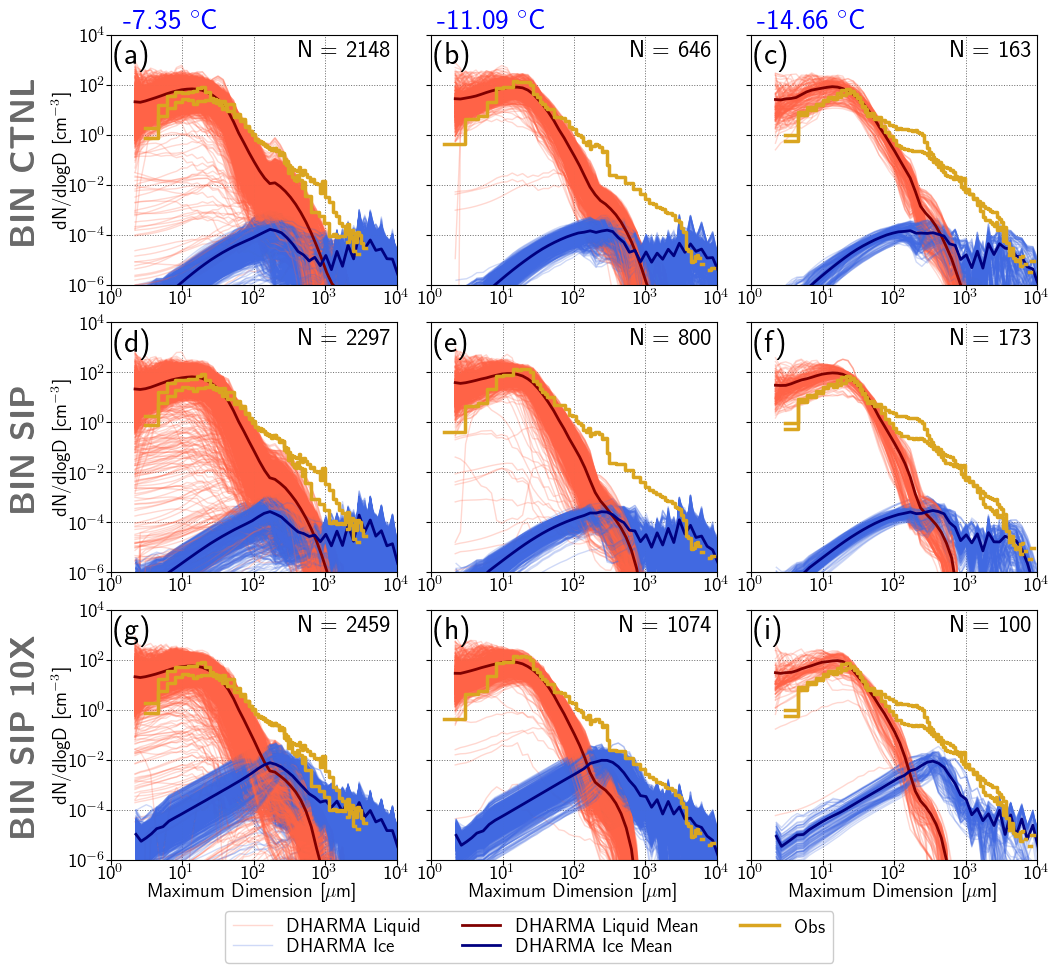

done


In [106]:
n_obs = 3
fig,axes = plt.subplots(nrows=3,ncols=n_obs,figsize=(3.5*n_obs, 9),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14

diam_liq = sip_bin_dict['lj_neg7']['diam_liq']
diam_ice = sip_bin_dict['lj_neg7']['diam_ice']
diam_tot = sip_bin_dict['lj_neg7']['diam_tot']

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])



left_axes = [axes_flat[0], axes_flat[n_obs], axes_flat[2*n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    #ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

bottom_axes = axes_flat[2*n_obs:]
for ax in bottom_axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]
axes_flat_3 = axes_flat[2*n_obs:]

obs_color = 'goldenrod'
dharma_mean_liq_color = 'maroon'
dharma_liq_color = 'tomato'
dharma_mean_ice_color = 'navy'
dharma_ice_color = 'royalblue'
dharma_alpha=0.25

# --- Row 1: CNTL ---
dumi=0
for key in cntl_bin_dict.keys():
    dNdlogD_liq_arr  = cntl_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = cntl_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA Liquid' if ii == 0 else None
        lbl2 = 'DHARMA Ice' if ii == 0 else None
        tmp_dNdlogD_liq_arr = dNdlogD_liq_arr[ii,:]
        tmp_dNdlogD_ice_arr = dNdlogD_ice_arr[ii,:]
        tmp_dNdlogD_liq_arr[tmp_dNdlogD_liq_arr == 0.] = np.nan
        tmp_dNdlogD_ice_arr[tmp_dNdlogD_ice_arr == 0.] = np.nan
        axes_flat_1[dumi].plot(diam_liq, tmp_dNdlogD_liq_arr, c=dharma_liq_color, lw=1, alpha=dharma_alpha, label=lbl)
        axes_flat_1[dumi].plot(diam_ice, tmp_dNdlogD_ice_arr, c=dharma_ice_color, lw=1, alpha=dharma_alpha, label=lbl2)
    axes_flat_1[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='DHARMA Liquid Mean')
    axes_flat_1[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='DHARMA Ice Mean')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1


# --- Row 2: SIP ---
dumi=0
for key in sip_bin_dict.keys():
    dNdlogD_liq_arr  = sip_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = sip_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA Liquid' if ii == 0 else None
        lbl2 = 'DHARMA Ice' if ii == 0 else None
        tmp_dNdlogD_liq_arr = dNdlogD_liq_arr[ii,:]
        tmp_dNdlogD_ice_arr = dNdlogD_ice_arr[ii,:]
        tmp_dNdlogD_liq_arr[tmp_dNdlogD_liq_arr == 0.] = np.nan
        tmp_dNdlogD_ice_arr[tmp_dNdlogD_ice_arr == 0.] = np.nan
        axes_flat_2[dumi].plot(diam_liq, tmp_dNdlogD_liq_arr, c=dharma_liq_color, lw=1, alpha=dharma_alpha, label=lbl)
        axes_flat_2[dumi].plot(diam_ice, tmp_dNdlogD_ice_arr, c=dharma_ice_color, lw=1, alpha=dharma_alpha, label=lbl2)
    axes_flat_2[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='DHARMA Liquid Mean')
    axes_flat_2[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='DHARMA Ice Mean')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1



# --- Row 3: SIP 10X ---
dumi=0
for key in sip_10x_bin_dict.keys():
    dNdlogD_liq_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])
    for ii in range(num_dsds):
        lbl = 'DHARMA Liquid' if ii == 0 else None
        lbl2 = 'DHARMA Ice' if ii == 0 else None
        tmp_dNdlogD_liq_arr = dNdlogD_liq_arr[ii,:]
        tmp_dNdlogD_ice_arr = dNdlogD_ice_arr[ii,:]
        tmp_dNdlogD_liq_arr[tmp_dNdlogD_liq_arr == 0.] = np.nan
        tmp_dNdlogD_ice_arr[tmp_dNdlogD_ice_arr == 0.] = np.nan
        axes_flat_3[dumi].plot(diam_liq, tmp_dNdlogD_liq_arr, c=dharma_liq_color, lw=1, alpha=dharma_alpha, label=lbl)
        axes_flat_3[dumi].plot(diam_ice, tmp_dNdlogD_ice_arr, c=dharma_ice_color, lw=1, alpha=dharma_alpha, label=lbl2)
    axes_flat_3[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='DHARMA Liquid Mean')
    axes_flat_3[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='DHARMA Ice Mean')
    axes_flat_3[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize*1.25,fontweight='bold',ha='right',va='top',transform=axes_flat_3[dumi].transAxes)

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes_flat_3[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1



for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')


# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.075), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=3)                     # Number of columns

#plt.suptitle('Updrafts Only ($w$ $>$ 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.3,0.5,r'\textbf{BIN CTNL}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.3,0.5,r'\textbf{BIN SIP}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')
axes_flat_3[0].text(-0.3,0.5,r'\textbf{BIN SIP 10X}',fontsize=Fontsize*1.75,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_3[0].transAxes,c='dimgrey')

save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_liq_ice_PSDs_bin.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

/tmp/ipykernel_1838237/3953437800.py:174: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


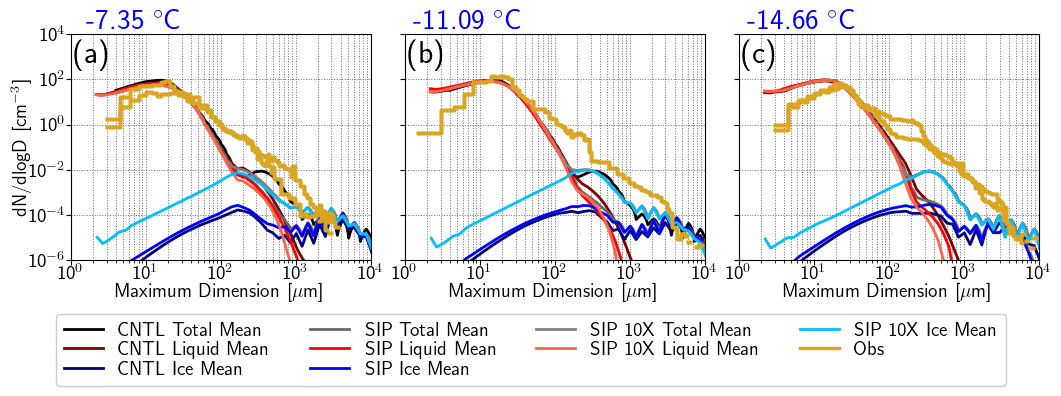

done


In [111]:
n_obs = 3
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=14

diam_liq = sip_bin_dict['lj_neg7']['diam_liq']
diam_ice = sip_bin_dict['lj_neg7']['diam_ice']
diam_tot = sip_bin_dict['lj_neg7']['diam_tot']

for ax in axes:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])


dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
axes[0].set_yticklabels(yticks)
axes[0].set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)



dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes:
    ax.set_xlabel('Maximum Dimension [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')



obs_color = 'goldenrod'
dharma_mean_color = 'k'
dharma_mean_liq_color = 'maroon'
dharma_mean_ice_color = 'navy'

# --- CNTL ---
dharma_mean_liq_color = 'maroon'
dharma_mean_ice_color = 'navy'
dumi=0
for key in cntl_bin_dict.keys():
    dNdlogDarr  = cntl_bin_dict[key]['up_w_dNdlogD']
    dNdlogD_liq_arr  = cntl_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = cntl_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_arr[np.isnan(dNdlogD_arr)] = 0.
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])

    axes[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='CNTL Total Mean')
    axes[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='CNTL Liquid Mean')
    axes[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='CNTL Ice Mean')

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1

# --- SIP ---
dharma_mean_liq_color = 'red'
dharma_mean_ice_color = 'blue'
dharma_mean_color = 'dimgrey'
dumi=0
for key in sip_bin_dict.keys():
    dNdlogD_arr  = sip_bin_dict[key]['up_w_dNdlogD']
    dNdlogD_liq_arr  = sip_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = sip_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_arr[np.isnan(dNdlogD_arr)] = 0.
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])

    axes[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='SIP Total Mean')
    axes[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='SIP Liquid Mean')
    axes[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='SIP Ice Mean')

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1


# --- SIP 10X ---
dharma_mean_liq_color = 'tomato'
dharma_mean_ice_color = 'deepskyblue'
dharma_mean_color = 'grey'
dumi=0
for key in sip_10x_bin_dict.keys():
    dNdlogD_liq_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_liq']
    dNdlogD_ice_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD_ice']
    dNdlogD_arr  = sip_10x_bin_dict[key]['up_w_dNdlogD']
    dNdlogD_liq_arr[np.isnan(dNdlogD_liq_arr)] = 0.
    dNdlogD_ice_arr[np.isnan(dNdlogD_ice_arr)] = 0.
    dNdlogD_arr[np.isnan(dNdlogD_arr)] = 0.
    mean_dNdlogD_liq = np.mean(dNdlogD_liq_arr, axis=0)
    mean_dNdlogD_ice = np.mean(dNdlogD_ice_arr, axis=0)
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdlogD_liq[mean_dNdlogD_liq == 0.] = np.nan
    mean_dNdlogD_ice[mean_dNdlogD_ice == 0.] = np.nan
    mean_dNdlogD[mean_dNdlogD == 0.] = np.nan
    num_dsds = len(dNdlogD_liq_arr[:,0])

    axes[dumi].plot(diam_tot, mean_dNdlogD, c=dharma_mean_color, lw=2., label='SIP 10X Total Mean')
    axes[dumi].plot(diam_liq, mean_dNdlogD_liq, c=dharma_mean_liq_color, lw=2., label='SIP 10X Liquid Mean')
    axes[dumi].plot(diam_ice, mean_dNdlogD_ice, c=dharma_mean_ice_color, lw=2., label='SIP 10X Ice Mean')

    # Plot observed
    for j, obs_key in enumerate(obs_dict.keys()):
        obs_key_split = obs_key.split('_')
        lbl = 'Obs' if j == 2 else None
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_dict[obs_key]
            axes[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c=obs_color, lw=2.5, label=lbl, where='mid', zorder=1000)
    dumi+=1
    
for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')


# 1. Collect unique handles and labels from all subplots
handles, labels = [], []
for ax in fig.axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h)
            labels.append(l)

# 2. Create the legend at the bottom of the figure.
#    constrained_layout will automatically make space for it.
fig.legend(handles, labels, 
           loc='lower center',          # Position at the bottom-center of the figure
           bbox_to_anchor=(0.5, -0.3), # Fine-tune position (0.5=center, negative y=below)
           framealpha=True, 
           fontsize=Fontsize,
           labelspacing=0.1,
           borderpad=0.4, 
           ncol=4)                     # Number of columns

plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)


save_path = '/global/homes/m/mckenna/figures/camp2ex_ice/'
outfile = 'fig_liq_ice_PSDs_bin.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')